# 🌱 Smart Irrigation — Random Forest Classification

**Objectif** : Prédire si une plante a besoin d'eau ou non (`besoin_eau`)

**Features utilisées** : Soil_Moisture, Crop_Growth_Stage, sol_chaud_sec, Mulching_Used, Wind_Speed_kmh, Rainfall_mm, Temperature_C

**Pipeline** :
1. Chargement des données & paramètres
2. Exploration rapide
3. Entraînement Random Forest
4. Évaluation & métriques
5. Graphes & visualisations
6. Sauvegarde du modèle + MLflow

## 📦 1. Imports

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import json
import yaml
import os
import mlflow
import mlflow.sklearn

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
print('✅ Imports OK')

✅ Imports OK


## 📂 2. Chargement des données & paramètres

In [30]:
# Chargement des paramètres depuis params_config.yaml
with open('../params_config.yaml', 'r') as f:
    params = yaml.safe_load(f)

# Extraction des paramètres
TARGET            = params['project']['target_column']    # 'besoin_eau'
RANDOM_STATE      = params['project']['random_state']     # 42
SELECTED_FEATURES = params['data']['selected_features']   # 7 features
EXPERIMENT_NAME   = params['mlflow']['experiment_name']   # 'ml_experiments'

print(f'🎯 Colonne cible     : {TARGET}')
print(f'🔢 Random state      : {RANDOM_STATE}')
print(f'🧪 MLflow experiment : {EXPERIMENT_NAME}')
print(f'📋 Features ({len(SELECTED_FEATURES)}) :')
for feat in SELECTED_FEATURES:
    print(f'   - {feat}')

🎯 Colonne cible     : besoin_eau
🔢 Random state      : 42
🧪 MLflow experiment : ml_experiments
📋 Features (7) :
   - Soil_Moisture
   - Crop_Growth_Stage
   - sol_chaud_sec
   - Mulching_Used
   - Wind_Speed_kmh
   - Rainfall_mm
   - Temperature_C


In [52]:
# Chargement des données
train_df = pd.read_csv('../../../data/sensor_data/train_selected.csv')
test_df  = pd.read_csv('../../../data/sensor_data/test_selected.csv')

print(f'✅ Train : {train_df.shape[0]} lignes, {train_df.shape[1]} colonnes')
print(f'✅ Test  : {test_df.shape[0]} lignes, {test_df.shape[1]} colonnes')
train_df.head()

✅ Train : 8000 lignes, 8 colonnes
✅ Test  : 2000 lignes, 8 colonnes


,Soil_Moisture,Crop_Growth_Stage,sol_chaud_sec,Mulching_Used,Wind_Speed_kmh,Rainfall_mm,Temperature_C,besoin_eau
0,8.78,2,25.505112,1,12.87,2423.51,27.96,0
1,61.71,3,10.518263,0,19.40,1930.96,27.47,1
2,26.18,3,10.600552,0,5.32,2234.30,14.36,0
3,38.28,1,12.220560,0,17.14,860.20,19.80,0
4,22.94,0,27.441066,0,1.88,301.20,35.61,1


## 🔍 3. Exploration rapide

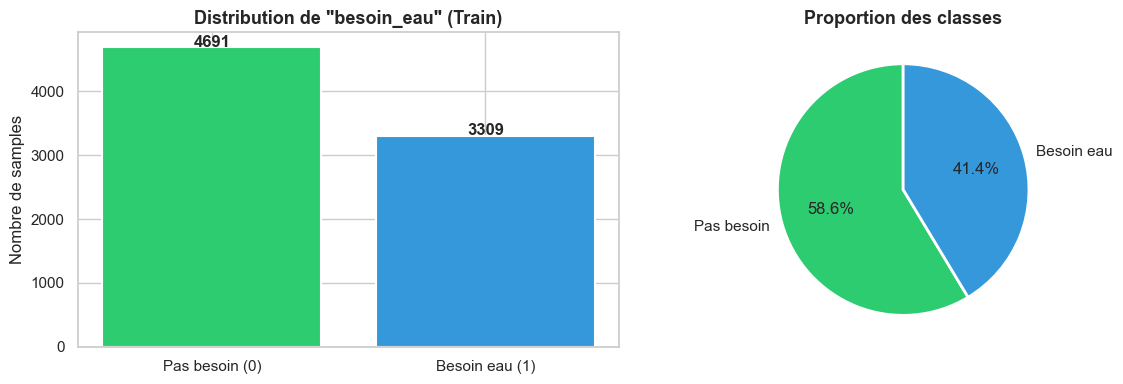

📊 Classe 0 (Pas besoin) : 4691 — 58.6%
📊 Classe 1 (Besoin eau) : 3309 — 41.4%


In [32]:
# Distribution de la variable cible 'besoin_eau'
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = train_df[TARGET].value_counts()

# Bar chart
axes[0].bar(['Pas besoin (0)', 'Besoin eau (1)'], counts.values,
            color=['#2ecc71', '#3498db'], edgecolor='white', linewidth=1.5)
axes[0].set_title(f'Distribution de "{TARGET}" (Train)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Nombre de samples')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['Pas besoin', 'Besoin eau'],
            autopct='%1.1f%%', colors=['#2ecc71', '#3498db'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proportion des classes', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'📊 Classe 0 (Pas besoin) : {counts[0]} — {counts[0]/len(train_df)*100:.1f}%')
print(f'📊 Classe 1 (Besoin eau) : {counts[1]} — {counts[1]/len(train_df)*100:.1f}%')

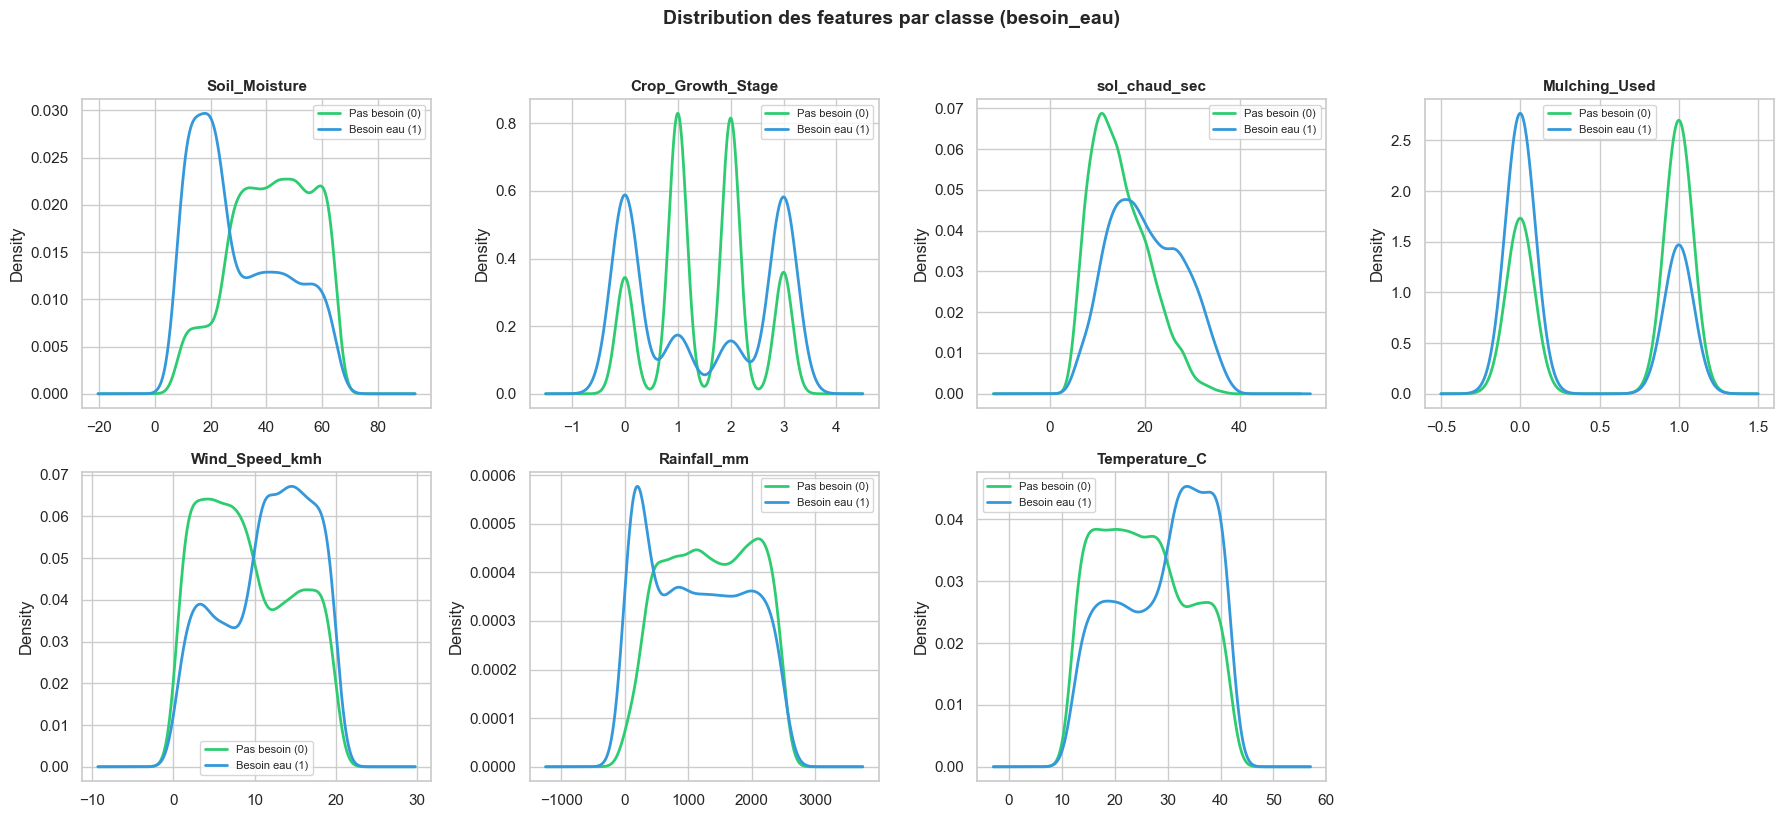

In [33]:
# Distribution des 7 features par classe
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feature in enumerate(SELECTED_FEATURES):
    if feature in train_df.columns:
        for cls, color, label in zip([0, 1], ['#2ecc71', '#3498db'],
                                     ['Pas besoin (0)', 'Besoin eau (1)']):
            subset = train_df[train_df[TARGET] == cls][feature]
            subset.plot(kind='kde', ax=axes[i], color=color, label=label, linewidth=2)
        axes[i].set_title(feature, fontsize=11, fontweight='bold')
        axes[i].set_xlabel('')
        axes[i].legend(fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Distribution des features par classe (besoin_eau)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('features_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## ✂️ 4. Préparation X / y

In [53]:
# Features disponibles dans le CSV
features_dispo = [f for f in SELECTED_FEATURES if f in train_df.columns]

X_train = train_df[features_dispo]
y_train = train_df[TARGET]
X_test  = test_df[features_dispo]
y_test  = test_df[TARGET]

print(f'✅ X_train : {X_train.shape}')
print(f'✅ X_test  : {X_test.shape}')
print(f'✅ Features : {features_dispo}')

✅ X_train : (8000, 7)
✅ X_test  : (2000, 7)
✅ Features : ['Soil_Moisture', 'Crop_Growth_Stage', 'sol_chaud_sec', 'Mulching_Used', 'Wind_Speed_kmh', 'Rainfall_mm', 'Temperature_C']


## 🌲 5. Entraînement Random Forest

In [35]:
# Hyperparamètres
# Tu peux ajouter une section 'random_forest' dans ton params_config.yaml
rf_params = {
    'n_estimators'     : 200,
    'max_depth'        : 10,
    'min_samples_split': 5,
    'min_samples_leaf' : 2,
    'max_features'     : 'sqrt',
    'class_weight'     : 'balanced',
    'random_state'     : RANDOM_STATE,
    'n_jobs'           : -1
}

print('🔧 Hyperparamètres Random Forest :')
for k, v in rf_params.items():
    print(f'   {k}: {v}')

🔧 Hyperparamètres Random Forest :
   n_estimators: 200
   max_depth: 10
   min_samples_split: 5
   min_samples_leaf: 2
   max_features: sqrt
   class_weight: balanced
   random_state: 42
   n_jobs: -1


In [36]:
# Entraînement
rf_model = RandomForestClassifier(**rf_params)
rf_model.fit(X_train, y_train)
print('✅ Modèle Random Forest entraîné avec succès !')

✅ Modèle Random Forest entraîné avec succès !


## 📊 6. Évaluation & Métriques

In [37]:
# Prédictions
y_pred      = rf_model.predict(X_test)
y_pred_prob = rf_model.predict_proba(X_test)[:, 1]

# Calcul des métriques
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_pred_prob)

print('=' * 50)
print('      📊 MÉTRIQUES RANDOM FOREST')
print('=' * 50)
print(f'  Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)')
print(f'  Precision : {precision:.4f}')
print(f'  Recall    : {recall:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print(f'  ROC-AUC   : {roc_auc:.4f}')
print('=' * 50)
print('\n📋 Rapport complet :')
print(classification_report(y_test, y_pred,
      target_names=['Pas besoin (0)', 'Besoin eau (1)']))

      📊 MÉTRIQUES RANDOM FOREST
  Accuracy  : 0.9990  (99.90%)
  Precision : 0.9976
  Recall    : 1.0000
  F1-Score  : 0.9988
  ROC-AUC   : 1.0000

📋 Rapport complet :
                precision    recall  f1-score   support

Pas besoin (0)       1.00      1.00      1.00      1173
Besoin eau (1)       1.00      1.00      1.00       827

      accuracy                           1.00      2000
     macro avg       1.00      1.00      1.00      2000
  weighted avg       1.00      1.00      1.00      2000



## 📈 7. Visualisations

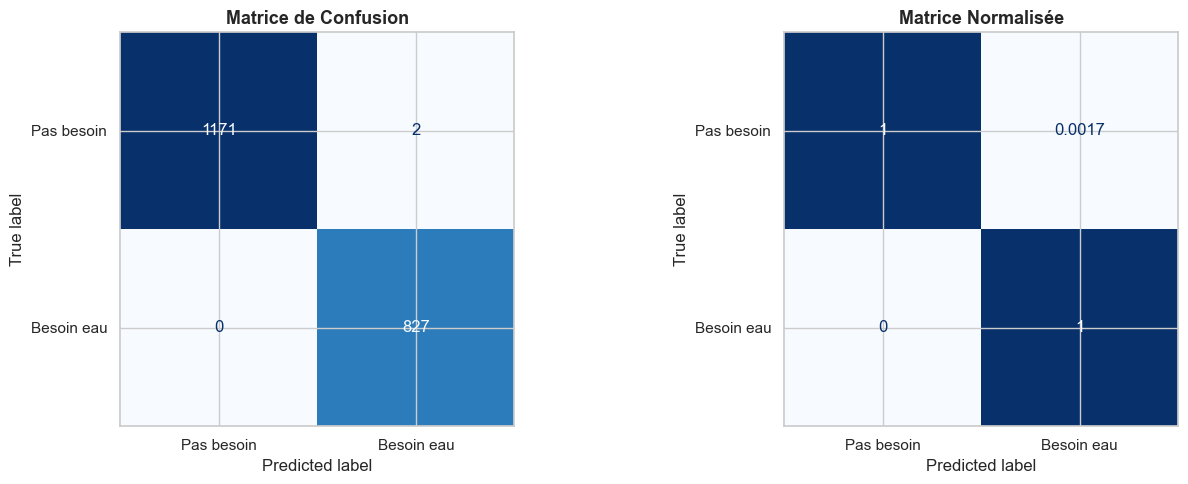

In [38]:
# --- Matrice de Confusion ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Pas besoin', 'Besoin eau']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matrice de Confusion', fontsize=13, fontweight='bold')

cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
ConfusionMatrixDisplay(cm_norm, display_labels=['Pas besoin', 'Besoin eau']).plot(
    ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Matrice Normalisée', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrix_rf.png', dpi=150, bbox_inches='tight')
plt.show()

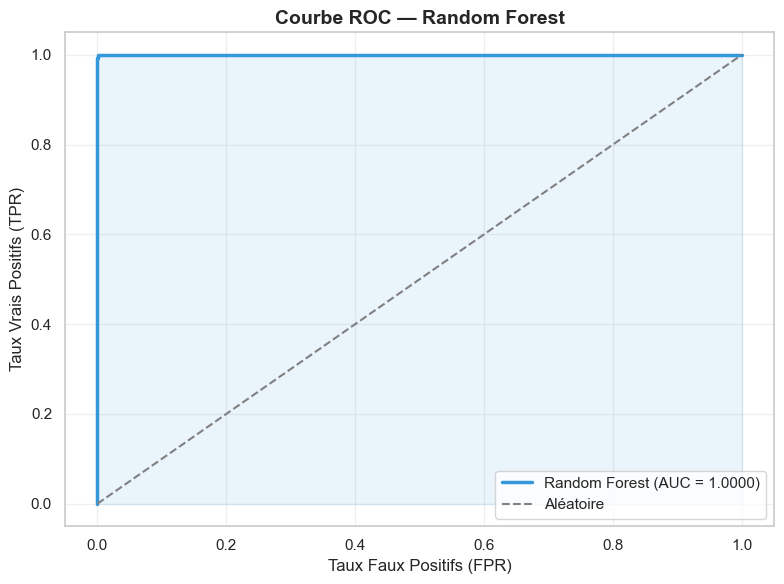

In [39]:
# --- Courbe ROC ---
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#3498db', lw=2.5,
         label=f'Random Forest (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Aléatoire')
plt.fill_between(fpr, tpr, alpha=0.1, color='#3498db')
plt.xlabel('Taux Faux Positifs (FPR)', fontsize=12)
plt.ylabel('Taux Vrais Positifs (TPR)', fontsize=12)
plt.title('Courbe ROC — Random Forest', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve_rf.png', dpi=150, bbox_inches='tight')
plt.show()

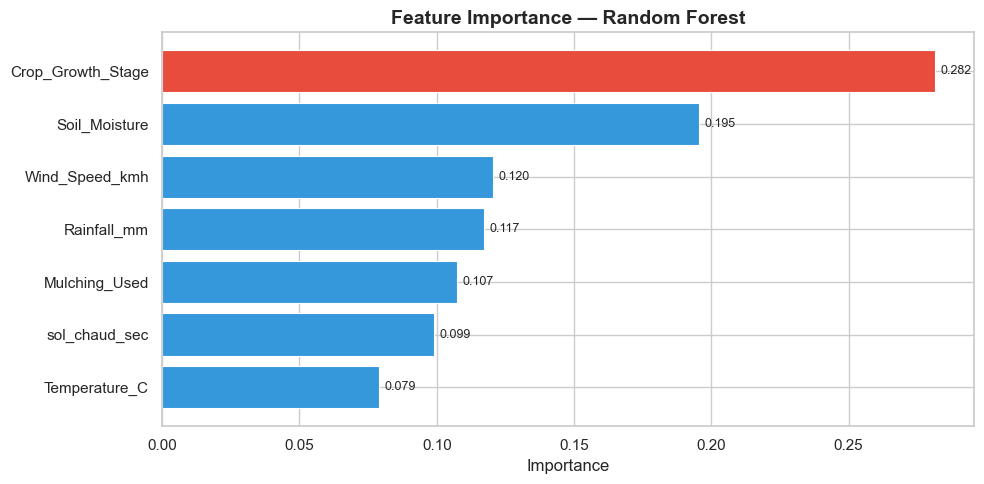


🔑 Ranking des features :
   1. Crop_Growth_Stage         : 0.2816
   2. Soil_Moisture             : 0.1955
   3. Wind_Speed_kmh            : 0.1204
   4. Rainfall_mm               : 0.1171
   5. Mulching_Used             : 0.1075
   6. sol_chaud_sec             : 0.0989
   7. Temperature_C             : 0.0791


In [40]:
# --- Feature Importance ---
importances = rf_model.feature_importances_
indices     = np.argsort(importances)[::-1]
sorted_feat = [features_dispo[i] for i in indices]
sorted_imp  = importances[indices]

plt.figure(figsize=(10, 5))
colors = ['#e74c3c' if i == 0 else '#3498db' for i in range(len(sorted_feat))]
bars = plt.barh(sorted_feat[::-1], sorted_imp[::-1],
                color=colors[::-1], edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, sorted_imp[::-1]):
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)
plt.xlabel('Importance', fontsize=12)
plt.title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance_rf.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n🔑 Ranking des features :')
for i, (feat, imp) in enumerate(zip(sorted_feat, sorted_imp)):
    print(f'   {i+1}. {feat:<25} : {imp:.4f}')

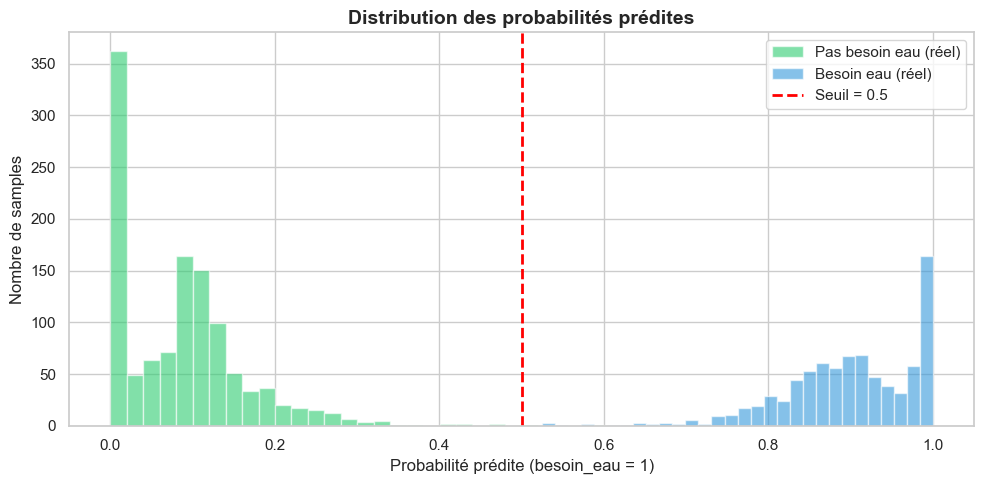

In [41]:
# --- Distribution des probabilités prédites ---
plt.figure(figsize=(10, 5))
plt.hist(y_pred_prob[y_test == 0], bins=30, alpha=0.6,
         color='#2ecc71', label='Pas besoin eau (réel)', edgecolor='white')
plt.hist(y_pred_prob[y_test == 1], bins=30, alpha=0.6,
         color='#3498db', label='Besoin eau (réel)', edgecolor='white')
plt.axvline(x=0.5, color='red', linestyle='--', lw=2, label='Seuil = 0.5')
plt.xlabel('Probabilité prédite (besoin_eau = 1)', fontsize=12)
plt.ylabel('Nombre de samples', fontsize=12)
plt.title('Distribution des probabilités prédites', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('prob_distribution_rf.png', dpi=150, bbox_inches='tight')
plt.show()

## 💾 8. Sauvegarde du modèle

In [42]:
os.makedirs('saved_model', exist_ok=True)

# Modèle
joblib.dump(rf_model, 'saved_model/random_forest_model.pkl')
print('✅ Modèle sauvegardé : saved_model/random_forest_model.pkl')

# Métriques
metrics = {
    'model'    : 'RandomForest',
    'accuracy' : round(accuracy,  4),
    'precision': round(precision, 4),
    'recall'   : round(recall,    4),
    'f1_score' : round(f1,        4),
    'roc_auc'  : round(roc_auc,   4)
}
with open('saved_model/metrics_rf.json', 'w') as f:
    json.dump(metrics, f, indent=4)
print('✅ Métriques sauvegardées : saved_model/metrics_rf.json')
print(json.dumps(metrics, indent=4))

✅ Modèle sauvegardé : saved_model/random_forest_model.pkl
✅ Métriques sauvegardées : saved_model/metrics_rf.json
{
    "model": "RandomForest",
    "accuracy": 0.999,
    "precision": 0.9976,
    "recall": 1.0,
    "f1_score": 0.9988,
    "roc_auc": 1.0
}


## 🔬 9. MLflow — Tracking

In [43]:
# Même experiment que MLP pour comparer les deux modèles dans MLflow UI
mlflow.set_experiment(EXPERIMENT_NAME)  # 'ml_experiments'

with mlflow.start_run(run_name='RandomForest_v1'):

    # Hyperparamètres
    mlflow.log_params(rf_params)

    # Métriques
    mlflow.log_metric('accuracy',  accuracy)
    mlflow.log_metric('precision', precision)
    mlflow.log_metric('recall',    recall)
    mlflow.log_metric('f1_score',  f1)
    mlflow.log_metric('roc_auc',   roc_auc)

    # Modèle
    mlflow.sklearn.log_model(rf_model, 'random_forest_model')

    # Graphes
    for img in ['confusion_matrix_rf.png', 'roc_curve_rf.png',
                'feature_importance_rf.png', 'prob_distribution_rf.png',
                'features_distribution.png', 'class_distribution.png']:
        if os.path.exists(img):
            mlflow.log_artifact(img)

    print(f'✅ MLflow run enregistré dans : "{EXPERIMENT_NAME}"')
    print(f'   Run ID : {mlflow.active_run().info.run_id}')
    print(f'\n💡 Lance "mlflow ui" pour comparer RF vs MLP !')

2026/05/16 17:26:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/16 17:26:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ MLflow run enregistré dans : "ml_experiments"
   Run ID : 75911b19bd91431d8aebf259b17d2753

💡 Lance "mlflow ui" pour comparer RF vs MLP !
🏃 View run RandomForest_v1 at: https://dagshub.com/Saadiaboussiar/Smart-Irrigation-Project.mlflow/#/experiments/4/runs/75911b19bd91431d8aebf259b17d2753
🧪 View experiment at: https://dagshub.com/Saadiaboussiar/Smart-Irrigation-Project.mlflow/#/experiments/4


## ✅ 10. Résumé final

In [44]:
print('=' * 52)
print('   🌲 RÉSUMÉ RANDOM FOREST — SMART IRRIGATION')
print('=' * 52)
print(f'  Cible      : {TARGET}')
print(f'  Features   : {len(features_dispo)} features')
print(f'  Arbres     : {rf_params["n_estimators"]}')
print(f'  Max depth  : {rf_params["max_depth"]}')
print(f'  Accuracy   : {accuracy*100:.2f}%')
print(f'  F1-Score   : {f1:.4f}')
print(f'  ROC-AUC    : {roc_auc:.4f}')
print('=' * 52)
print(f'\n📁 Fichiers générés :')
print(f'   saved_model/random_forest_model.pkl')
print(f'   saved_model/metrics_rf.json')
print(f'   confusion_matrix_rf.png')
print(f'   roc_curve_rf.png')
print(f'   feature_importance_rf.png')


   🌲 RÉSUMÉ RANDOM FOREST — SMART IRRIGATION
  Cible      : besoin_eau
  Features   : 7 features
  Arbres     : 200
  Max depth  : 10
  Accuracy   : 99.90%
  F1-Score   : 0.9988
  ROC-AUC    : 1.0000

📁 Fichiers générés :
   saved_model/random_forest_model.pkl
   saved_model/metrics_rf.json
   confusion_matrix_rf.png
   roc_curve_rf.png
   feature_importance_rf.png


# 🔬 MLflow + DagsHub — Random Forest
Ce fichier montre uniquement la section MLflow à copier dans ton notebook RF.
Remplace la section MLflow existante par ce code.

## 📦 Imports à ajouter en haut de ton notebook

In [45]:
from dotenv import load_dotenv
from pathlib import Path
import os
import mlflow
import mlflow.sklearn
import joblib

## ➕ Calculs à ajouter avant le bloc MLflow
Ces variables sont utilisées dans le log MLflow ci-dessus

In [46]:
from sklearn.metrics import confusion_matrix

# Matrice de confusion pour extraire TP, TN, FP, FN
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

# Métriques par classe
# Classe 1 = besoin eau (needs_water)
needs_water_precision = precision_score(y_test, y_pred, pos_label=1)
needs_water_recall    = recall_score(y_test, y_pred,    pos_label=1)
needs_water_f1        = f1_score(y_test, y_pred,        pos_label=1)

# Classe 0 = pas besoin eau (no_water)
no_water_precision    = precision_score(y_test, y_pred, pos_label=0)
no_water_recall       = recall_score(y_test, y_pred,    pos_label=0)

print(f'TP={TP}, TN={TN}, FP={FP}, FN={FN}')
print(f'needs_water → precision={needs_water_precision:.4f}, recall={needs_water_recall:.4f}, f1={needs_water_f1:.4f}')
print(f'no_water    → precision={no_water_precision:.4f},    recall={no_water_recall:.4f}')

TP=827, TN=1171, FP=2, FN=0
needs_water → precision=0.9976, recall=1.0000, f1=0.9988
no_water    → precision=1.0000,    recall=0.9983


## 🔬 Section MLflow + DagsHub — à remplacer dans ton notebook RF

In [47]:
import mlflow
import joblib
from dotenv import load_dotenv
import os
from pathlib import Path
# Charger les variables d'environnement depuis .env
# Même chemin que ton camarade — adapte si besoin
load_dotenv(dotenv_path=Path('C:/Users/user/Desktop/Smart-Irrigation-Project/mlflow_setup/.env'))


dagshub_username = os.getenv("DAGSHUB_USERNAME")
dagshub_repo_owner  = os.getenv("DAGSHUB_REPO_OWNER")
dagshub_repo_name = os.getenv('DAGSHUB_REPO_NAME')
print(dagshub_username)
print(dagshub_repo_name)
print(dagshub_repo_owner)
os.environ['MLFLOW_TRACKING_USERNAME'] = dagshub_username
os.environ['MLFLOW_TRACKING_PASSWORD'] = os.getenv('DAGSHUB_USER_TOKEN')

# Même tracking URI que ton camarade → même DagsHub repo
mlflow.set_tracking_uri(
    'https://dagshub.com/' + dagshub_repo_owner + '/' + dagshub_repo_name + '.mlflow'
)

# Même experiment → pour comparer RF vs MLP dans le même tableau
mlflow.set_experiment(os.getenv('MLFLOW_EXPERIMENT_NAME'))

# Sauvegarder le scaler si tu en utilises un
joblib.dump(rf_model, 'rf_model.pkl')

with mlflow.start_run(run_name='RandomForest_v1'):

    # 1. Log parameters
    mlflow.log_param('model_type',         'RandomForest')
    mlflow.log_param('n_estimators',        rf_params['n_estimators'])
    mlflow.log_param('max_depth',           rf_params['max_depth'])
    mlflow.log_param('min_samples_split',   rf_params['min_samples_split'])
    mlflow.log_param('min_samples_leaf',    rf_params['min_samples_leaf'])
    mlflow.log_param('max_features',        rf_params['max_features'])
    mlflow.log_param('class_weight',        rf_params['class_weight'])
    mlflow.log_param('selected_features',   features_dispo)
    mlflow.log_param('smote',               True)
    mlflow.log_param('scaler',              'StandardScaler')

    # 2. Log metrics — mêmes noms que ton camarade pour comparer
    mlflow.log_metric('accuracy',               accuracy)
    mlflow.log_metric('recall_needs_water',      recall)
    mlflow.log_metric('precision_needs_water',   precision)
    mlflow.log_metric('needs_water_f1',          f1)
    mlflow.log_metric('no_water_precision',      no_water_precision)
    mlflow.log_metric('no_water_recall',         no_water_recall)
    mlflow.log_metric('roc_auc',                 roc_auc)
    mlflow.log_metric('TP',                      TP)
    mlflow.log_metric('TN',                      TN)
    mlflow.log_metric('FP',                      FP)
    mlflow.log_metric('FN',                      FN)

    # 3. Log model
    mlflow.sklearn.log_model(
        rf_model,
        artifact_path='rf_model',
        registered_model_name='random_forest_model'
    )

    # 4. Log graphes
    for img in ['confusion_matrix_rf.png', 'roc_curve_rf.png',
                'feature_importance_rf.png', 'prob_distribution_rf.png',
                'features_distribution.png']:
        if os.path.exists(img):
            mlflow.log_artifact(img)

    # 5. Log config
    mlflow.log_artifact('saved_model/metrics_rf.json')

    print('✅ Everything logged to DagsHub MLflow!')

yass031
Smart-Irrigation-Project
Saadiaboussiar


2026/05/16 17:27:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/16 17:27:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'random_forest_model' already exists. Creating a new version of this model...
2026/05/16 17:27:45 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: random_forest_model, version 2
Created version '2' of model 'random_forest_model'.


✅ Everything logged to DagsHub MLflow!
🏃 View run RandomForest_v1 at: https://dagshub.com/Saadiaboussiar/Smart-Irrigation-Project.mlflow/#/experiments/0/runs/b47f3d9b5f7f4d72a0d81f2ec9d394ca
🧪 View experiment at: https://dagshub.com/Saadiaboussiar/Smart-Irrigation-Project.mlflow/#/experiments/0


### met le modele randomforest en production :

In [55]:
from mlflow.tracking import MlflowClient

client = MlflowClient()

# Enregistrer le modèle en Production
client.transition_model_version_stage(
    name="random_forest_model",
    version=1,
    stage="Production"
)
print("✅ Modèle RF en Production sur DagsHub !")

✅ Modèle RF en Production sur DagsHub !
